In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

data_path = Path(r"C:\Users\elyse\Downloads\Python\Capstone\capstone_throttleable_engine_2025-26\software\src\logs\2026\05\19\19-03-54_data.csv")

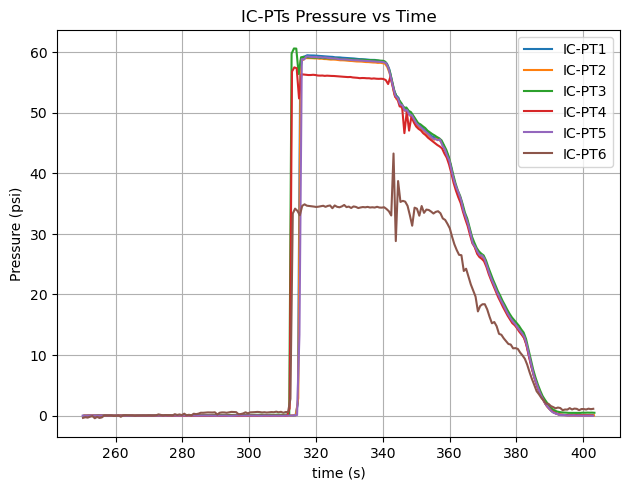

In [23]:
cols = "sensor_name,sensor_kind,t_monotonic,t_wall,raw_value,value,units,status,message,filtered_value,sequence,source".split(",")
df = pd.read_csv(data_path, header=0, names=cols)
data_matrix = df.to_numpy()

df["t_rel"] = df.t_wall - df.t_wall.min()

t, value, raw_value, voltage = {}, {}, {}, {}

plt.figure()
for name, g in df.groupby("sensor_name"):
    g = g.sort_values("t_rel")
    t[name] = g.t_rel.to_numpy()
    value[name] = g.value.to_numpy()
    raw_value[name] = g.raw_value.to_numpy()

    mask = t[name] > 250
    t[name] = t[name][mask]
    value[name] = value[name][mask]
    raw_value[name] = raw_value[name][mask]

    voltage[name] = raw_value[name] * 5.0 / ((1 << 23) - 1)
    frac = (voltage[name] - np.mean(voltage[name][10:20])) / 4

    if name == "IC-PT6":
        value[name] = frac * 1000
    else:
        value[name] = frac * 80

    plt.plot(t[name], value[name], label=name)
    plt.xlabel("time (s)")
    plt.ylabel("Pressure (psi)")
    plt.grid(True)
    plt.tight_layout()


plt.title("IC-PTs Pressure vs Time")
plt.legend()
plt.show()